# VIDEMUS — Detection Model
### AR Driving Guidance — Baseline Model

This notebook fine-tunes a YOLOv8 model to detect traffic lights, pedestrians and cars.

**Requirements:** Run on Google Colab with GPU runtime enabled.
Go to Runtime → Change runtime type → T4 GPU

#1. Install required packages

In [1]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 57.3 MB/s eta 0:00:00


### Verify GPU availability

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


#2. Download the Dataset
We use a pre-labeled traffic light dataset from Roboflow. <br>
It contains annotated images of traffic lights in three states:<br>
red, yellow, and green — captured from driving footage. <br>
cars and pedestrians

In [3]:
from roboflow import Roboflow
import os

In [4]:
ROBOFLOW_API_KEY = 'coHcfr9N7aqQ74FGS802'
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Download the detection dataset

In [5]:
project = rf.workspace("frank-yu").project("self-driving-car-9hgbb")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Self-driving-car-1 in yolov8:: 100%|██████████| 19767/19767 [00:01<00:00, 10694.81it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
print(f"\nDataset downloaded to: {dataset.location}")


Dataset downloaded to: /content/Self-driving-car-1


# Explore the dataset structure

In [7]:
dataset_path = dataset.location
print("Dataset contents:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        file_count = len(files)
        if file_count > 5:
            print(f"{subindent}({file_count} files)")
        else:
            for file in files:
                print(f"{subindent}{file}")

Dataset contents:
Self-driving-car-1/
  data.yaml
  README.roboflow.txt
  README.dataset.txt
  train/
    labels/
    images/
  test/
    labels/
    images/
  valid/
    labels/
    images/


# Read the data.yaml to see class names

In [8]:
yaml_path = os.path.join(dataset_path, "data.yaml")
if os.path.exists(yaml_path):
    print(f"\n--- data.yaml ---")
    with open(yaml_path, 'r') as f:
        print(f.read())


--- data.yaml ---
names:
- biker
- car
- pedestrian
- trafficLight
- trafficLight-Green
- trafficLight-GreenLeft
- trafficLight-Red
- trafficLight-RedLeft
- trafficLight-Yellow
- trafficLight-YellowLeft
- truck
nc: 11
roboflow:
  license: CC BY 4.0
  project: self-driving-car-9hgbb
  url: https://universe.roboflow.com/frank-yu/self-driving-car-9hgbb/dataset/1
  version: 1
  workspace: frank-yu
test: ../test/images
train: ../train/images
val: ../valid/images



# 3. Fine-tune YOLOv8 on Traffic Light Detection

 We start from a pre-trained YOLOv8n (nano) model then fine-tune <br>
 it specifically for traffic light detection.<br>

# **Why YOLOv8n (nano)?**

- Lightweight and fast — ideal for real-time AR applications <br>
- Runs well on phones and edge devices <br>
- Can be upgraded to YOLOv8s/m later for higher accuracy

In [9]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model

In [10]:
model = YOLO("yolov8n.pt")

# Train the model

In [11]:
results = model.train(
    data=os.path.join(dataset_path, "data.yaml"),
    epochs=20,
    imgsz=640,
    batch=16,
    patience=10,
    name="videmus_traffic_light",
    verbose=True
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Self-driving-car-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=videmus_traffic_light, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [12]:
print("\nTraining complete!")


Training complete!


# 4. Evaluate Model Performance
### Key metrics:
- **mAP50**: Mean Average Precision at 50% IoU — above 0.7 is strong
- **Precision**: Of all detections, how many were correct
- **Recall**: Of all real objects, how many did we detect

### Evaluate on validation set

In [13]:
metrics = model.val()

print(f"\n{'='*50}")
print(f"  VIDEMUS Model — Evaluation Results")
print(f"{'='*50}")
print(f"  mAP50:      {metrics.box.map50:.4f}")
print(f"  mAP50-95:   {metrics.box.map:.4f}")
print(f"  Precision:  {metrics.box.mp:.4f}")
print(f"  Recall:     {metrics.box.mr:.4f}")
print(f"{'='*50}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 975.9±266.9 MB/s, size: 24.7 KB)
val: Scanning /content/Self-driving-car-1/valid/labels.cache... 1976 images, 232 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1976/1976 690.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 124/124 7.4it/s 16.8s
                   all       1976      13082      0.754      0.469      0.534      0.286
                 biker        162        266      0.692      0.425      0.498      0.242
                   car       1701       8533       0.85       0.76      0.826      0.522
            pedestrian        448       1472       0.65      0.456      0.522      0.238
          trafficLight        212        339      0.754      0.617      0.695      0.388
    trafficLight-Green        

### Visualize training results

In [14]:
from IPython.display import Image, display
import glob

results_dir = "runs/detect/videmus_traffic_light"

### Training loss and metrics curves

Training curves:


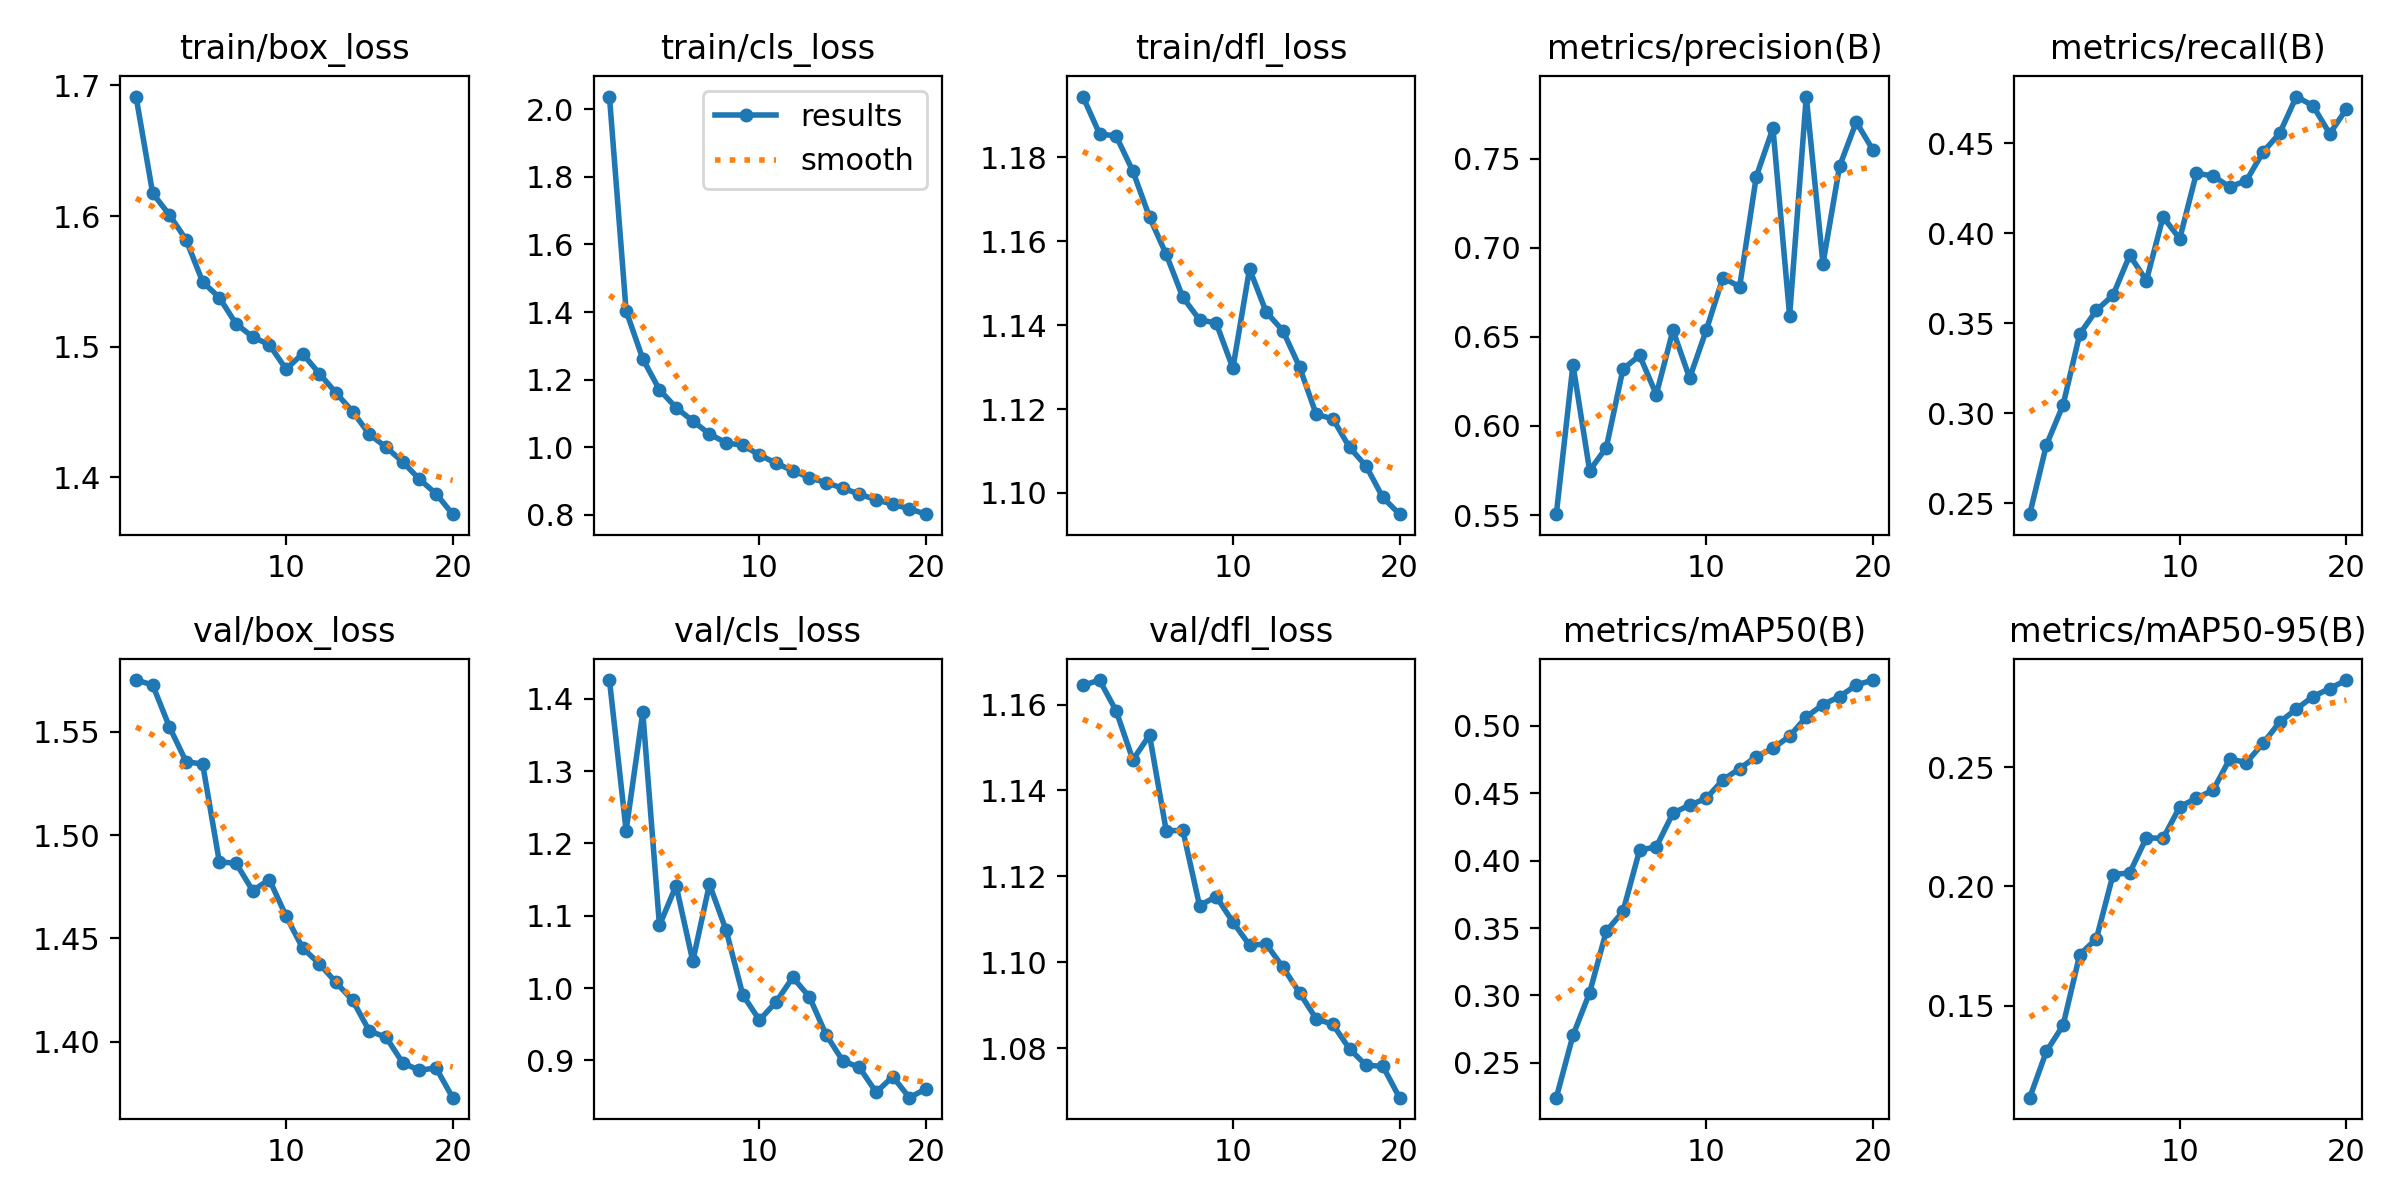

In [15]:
results_img = os.path.join(results_dir, "results.png")
if os.path.exists(results_img):
    print("Training curves:")
    display(Image(filename=results_img, width=900))

### Confusion matrix


Confusion matrix:


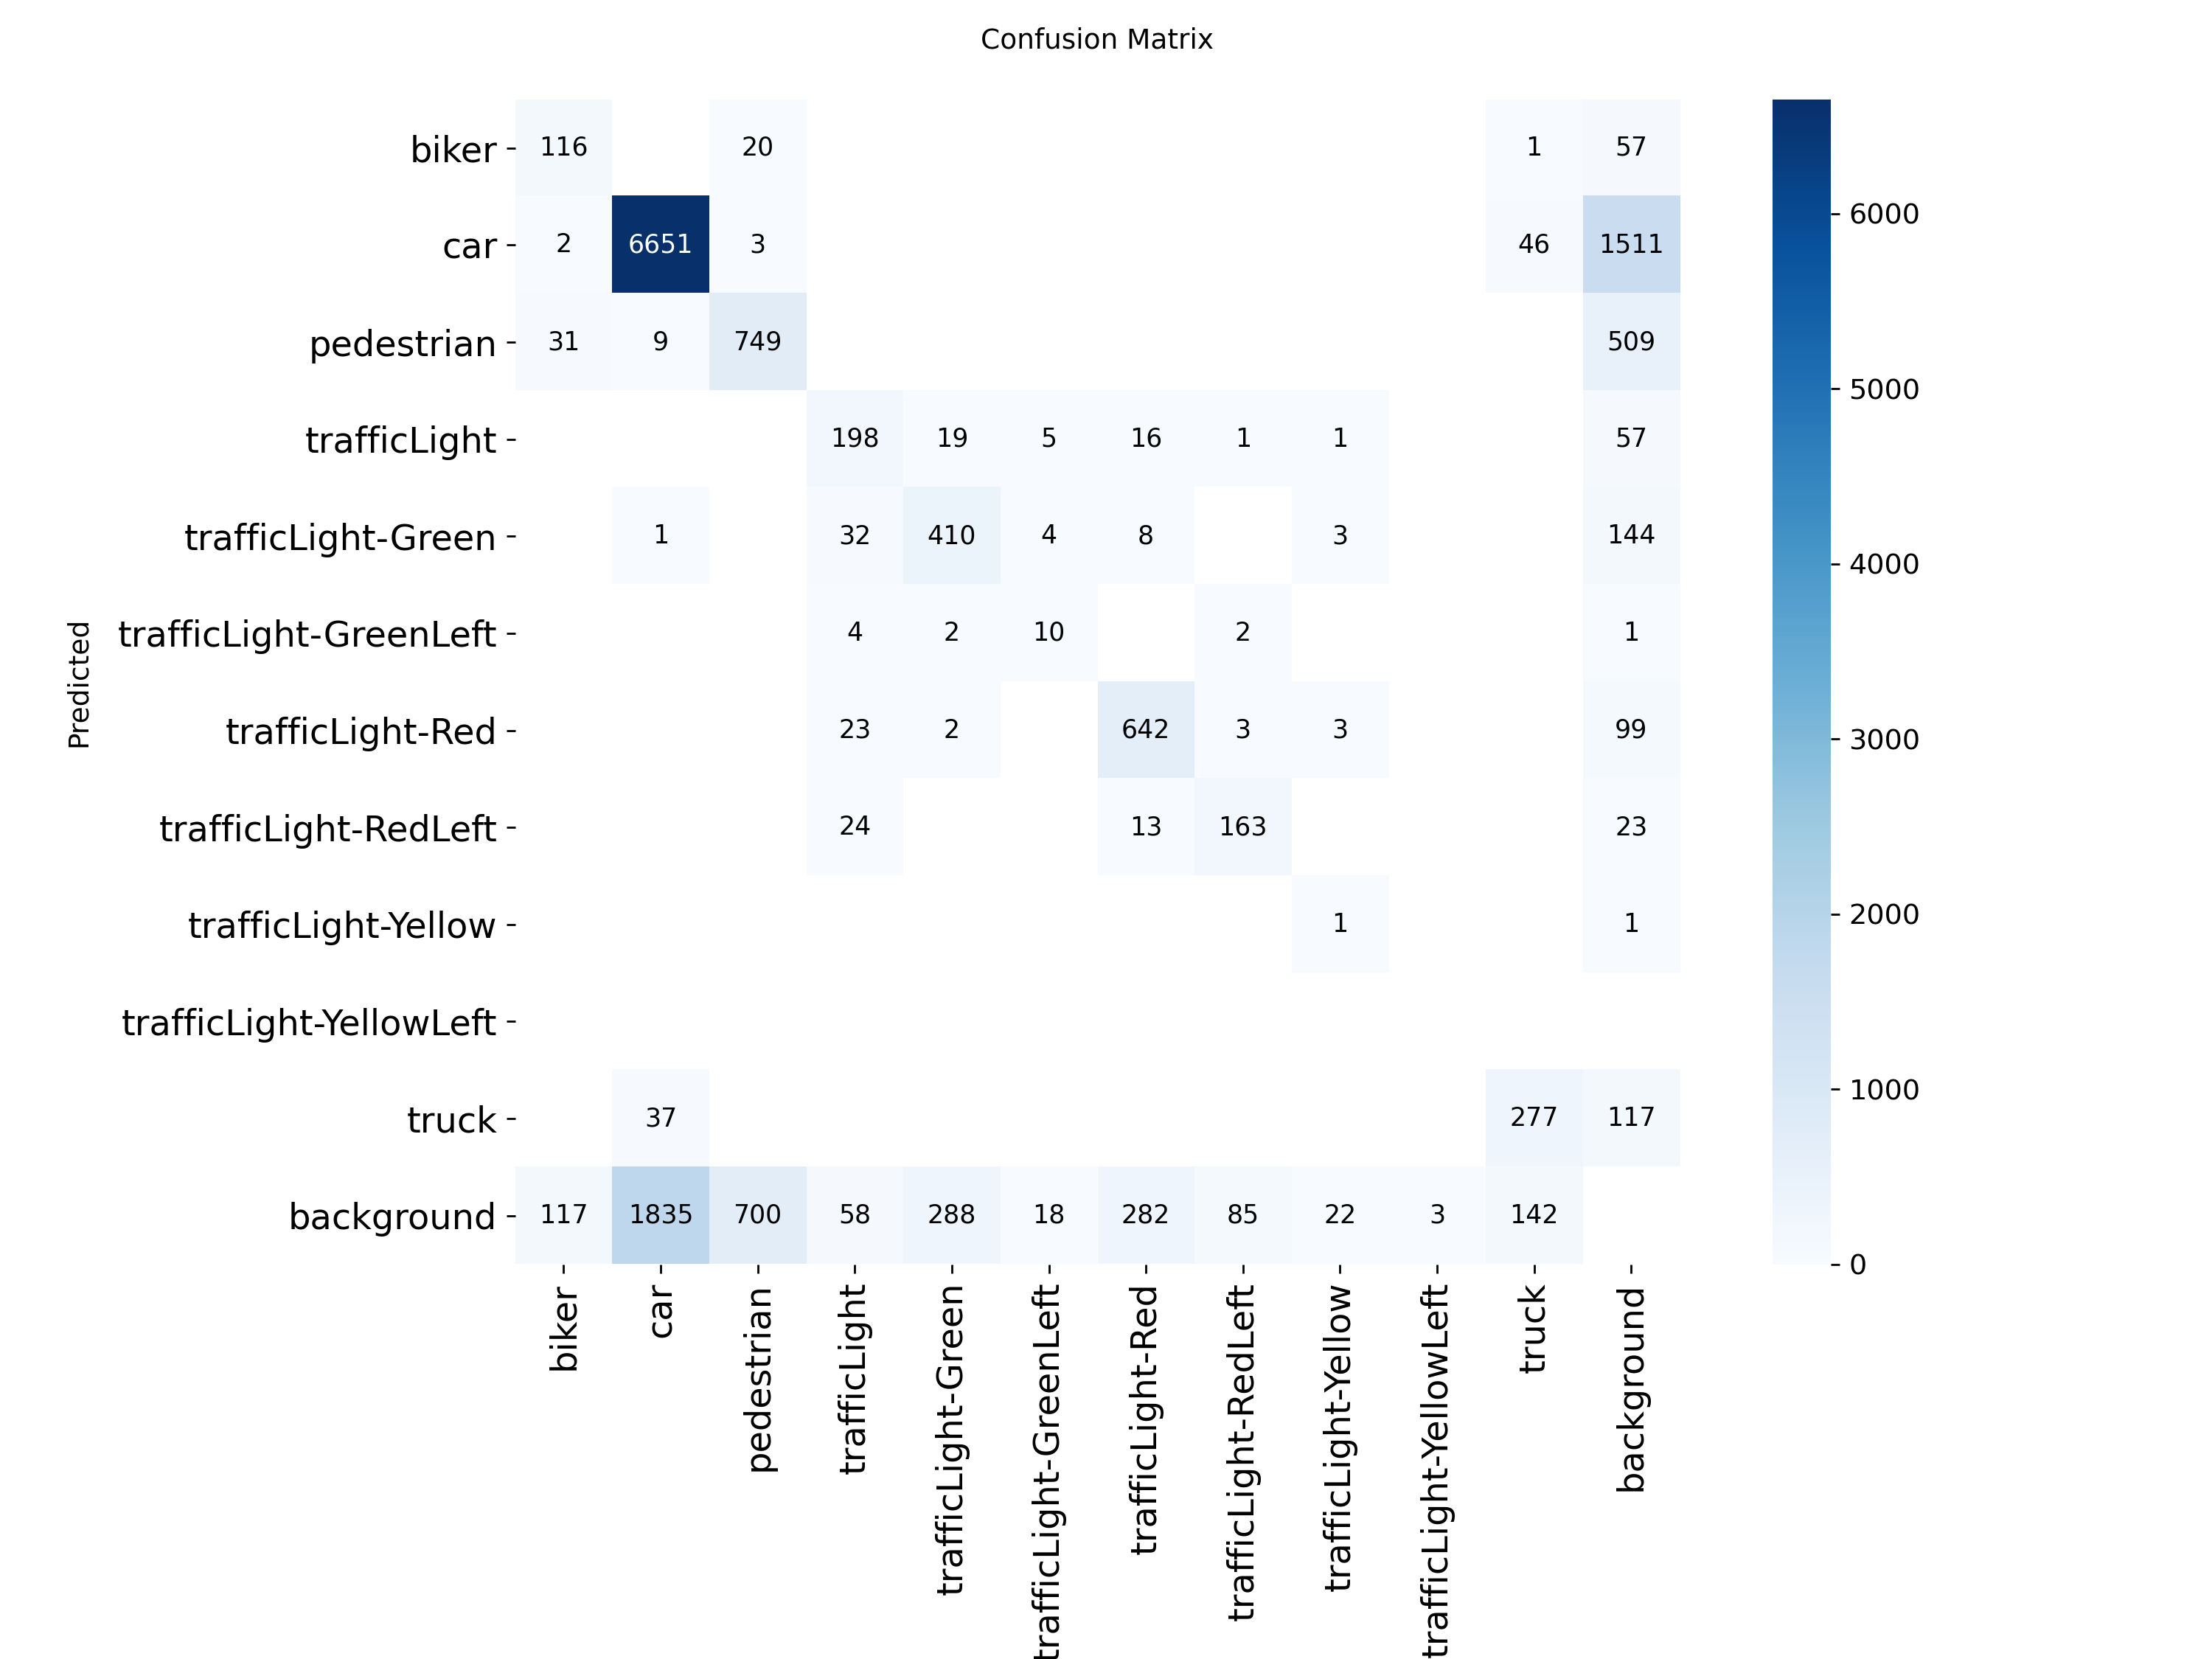

In [16]:
conf_img = os.path.join(results_dir, "confusion_matrix.png")
if os.path.exists(conf_img):
    print("\nConfusion matrix:")
    display(Image(filename=conf_img, width=600))

### Show sample predictions on validation images

Sample predictions on validation images:


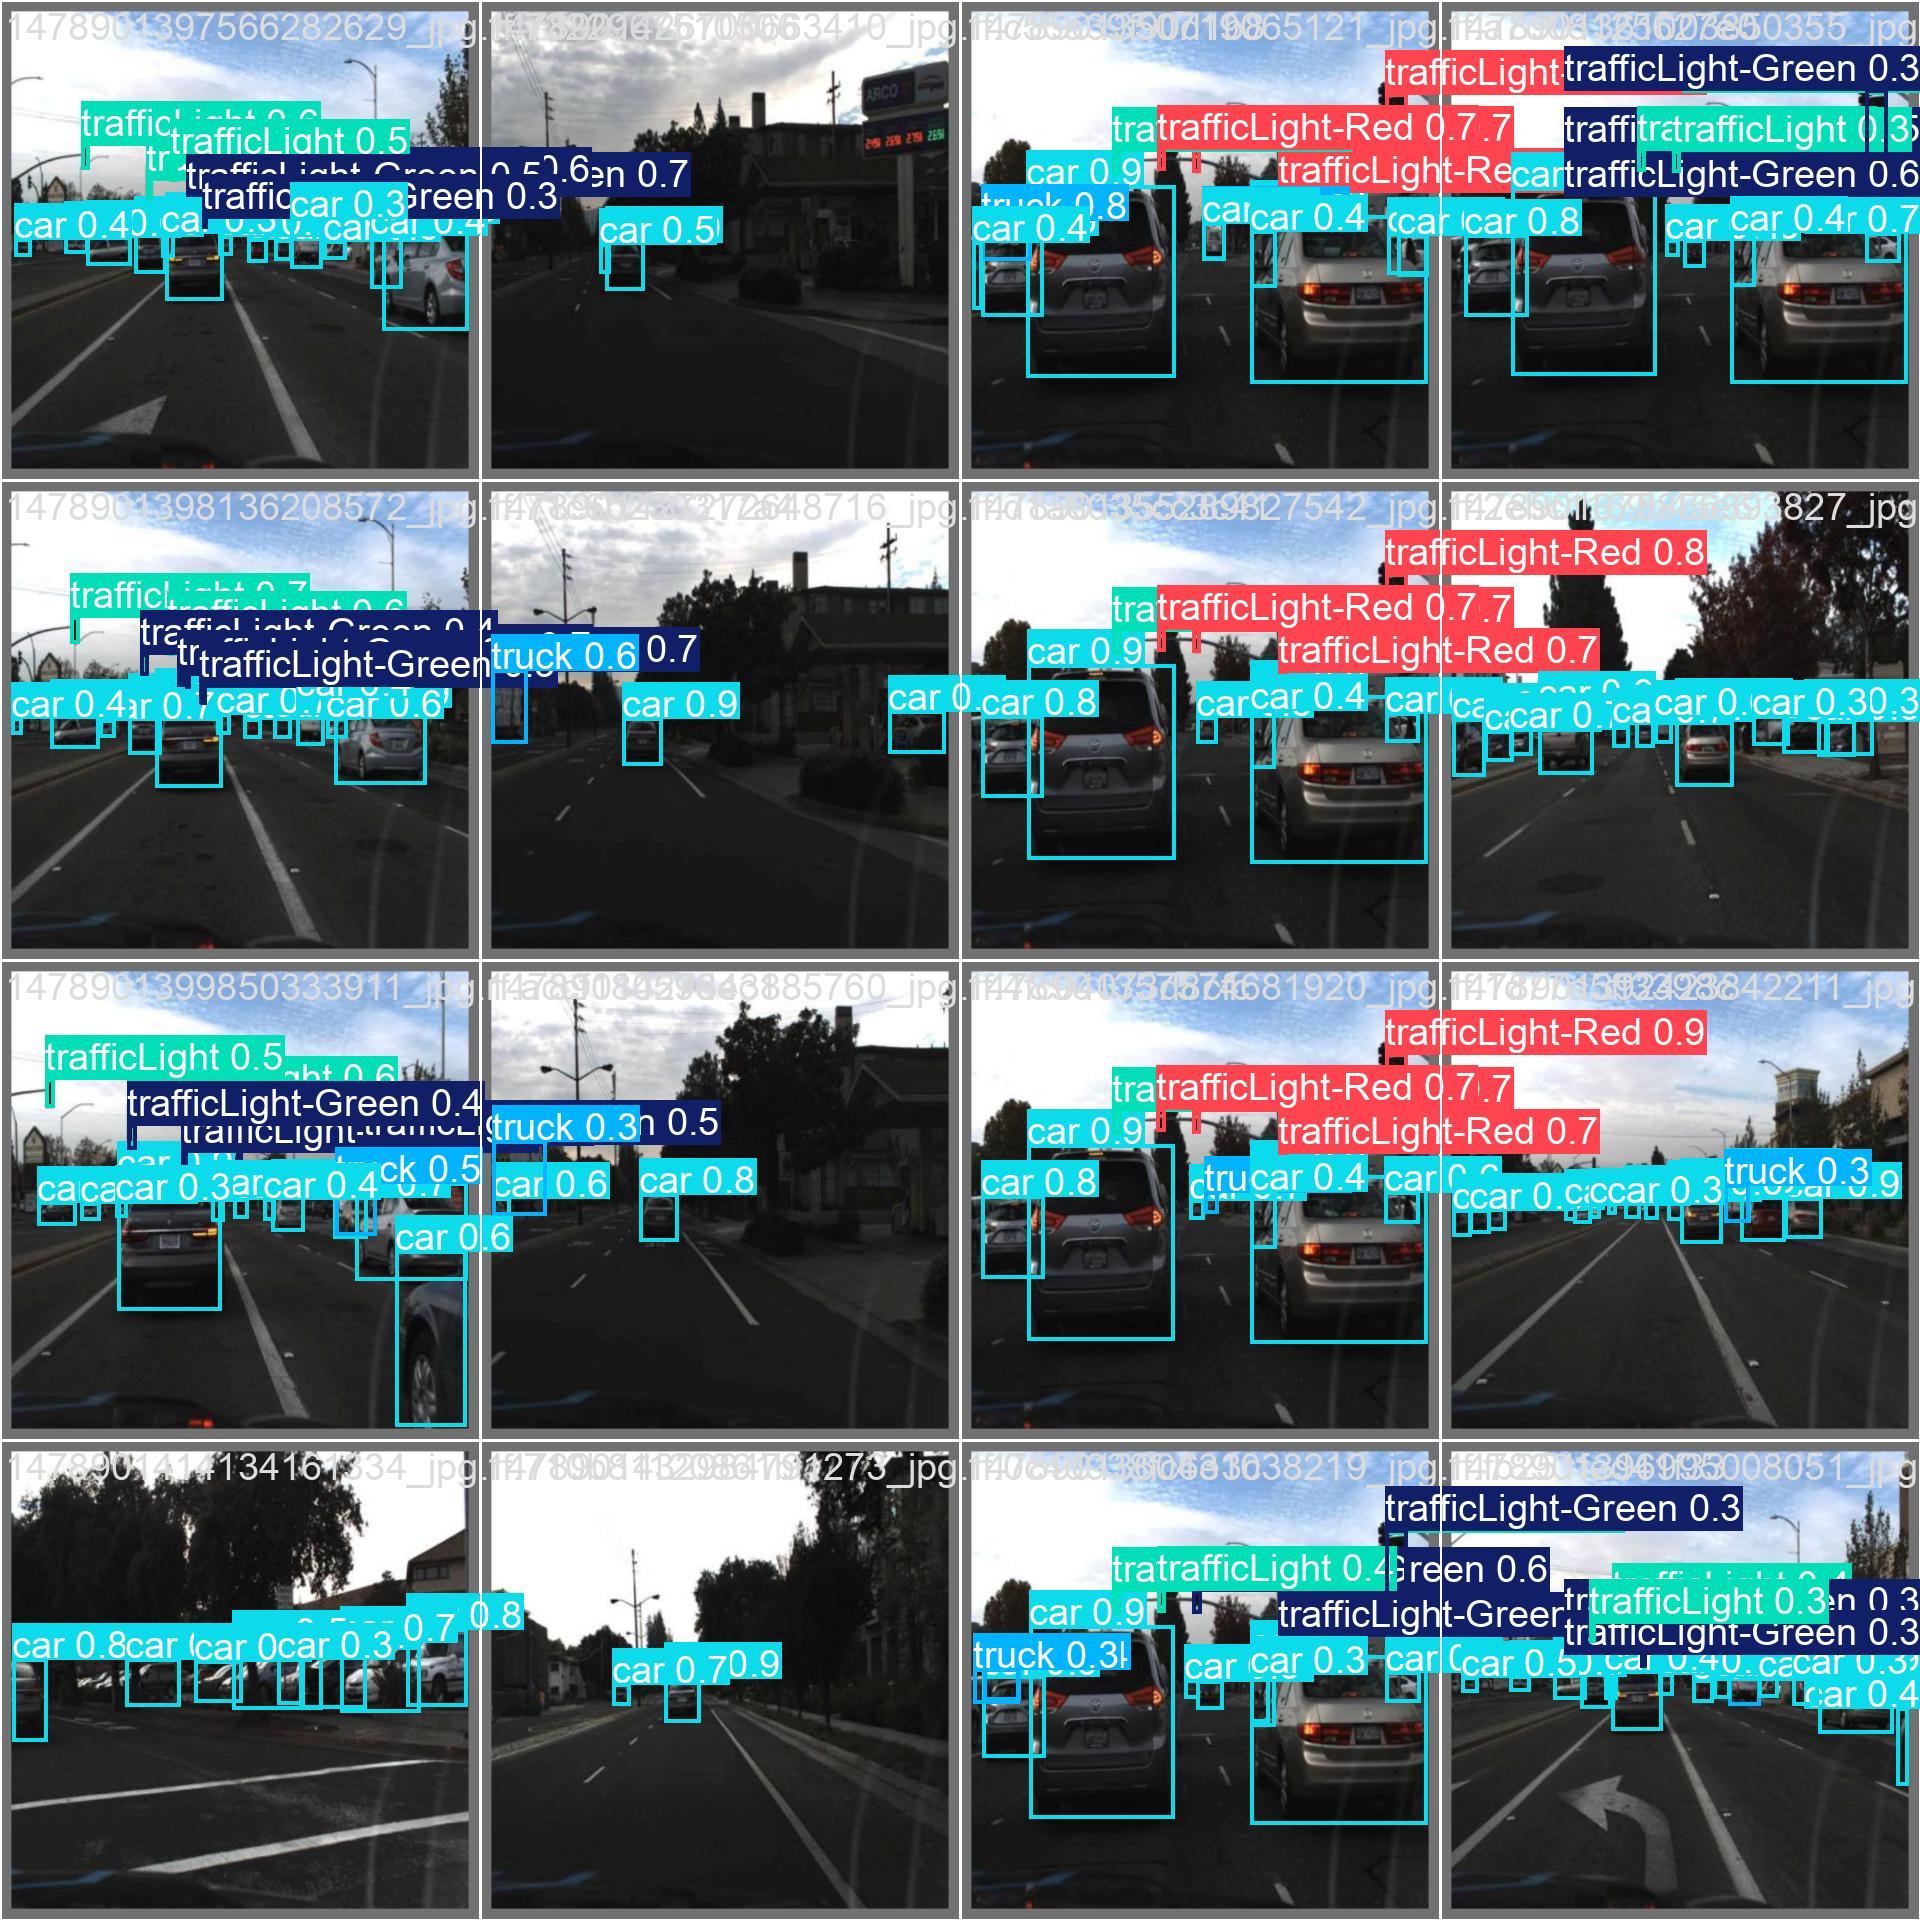

In [17]:
val_preds = os.path.join(results_dir, "val_batch0_pred.jpg")
if os.path.exists(val_preds):
    print("Sample predictions on validation images:")
    display(Image(filename=val_preds, width=900))

# 5. Test on Real Driving Footage
Upload a driving video to test the trained model. <br>
The model will draw bounding boxes around detected traffic lights.<br>
Upload your own video<br>


In [18]:
from google.colab import files
print("Upload a driving video (mp4):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Uploaded: {video_path}")

Upload a driving video (mp4):


Saving Неозаглавен дизайн.mp4 to Неозаглавен дизайн.mp4
Uploaded: Неозаглавен дизайн.mp4


# Run detection on the video

In [19]:
import cv2
from ultralytics import YOLO

# Load the best trained model

In [20]:
best_model_path = os.path.join(results_dir, "weights", "best.pt")
model = YOLO(best_model_path)

print(f"Loaded model: {best_model_path}")
print(f"Processing video: {video_path}")
print("This may take a few minutes...\n")

Loaded model: runs/detect/videmus_traffic_light/weights/best.pt
Processing video: Неозаглавен дизайн.mp4
This may take a few minutes...



# Run inference on video

In [21]:
results = model.predict(
    source=video_path,
    save=True,
    conf=0.35,
    line_width=2,
    show_labels=True,
    show_conf=True,
    name="videmus_output"
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/600) /content/Неозаглавен дизайн.mp4: 384x640 5 cars, 46.0ms
video 1/1 (frame 2/600) /content/Неозаглавен дизайн.mp4: 384x640 4 cars, 6.8ms
video 1/1 (frame 3/600) /content/Неозаглавен дизайн.mp4: 384x640 5 cars, 6.2ms
video 1/1 (frame 4/600) /content/Неозаглавен дизайн.mp4: 384x640 6 cars, 6.4ms
video 1/1 (frame 5/600) /content/Неозаглавен дизайн.mp4: 384x640 6 cars, 6.3ms
video 1/1 (frame 6/600) /content/Неозаглавен дизайн.mp4: 384x6

# Find the output video

In [22]:
output_dir = "runs/detect/videmus_output"
output_files = glob.glob(os.path.join(output_dir, "*.avi")) + \
               glob.glob(os.path.join(output_dir, "*.mp4"))

if output_files:
    output_video = output_files[0]
    print(f"\nOutput saved to: {output_video}")
else:
    print("\nCheck runs/detect/videmus_output/ for results.")


Output saved to: runs/detect/videmus_output/Неозаглавен дизайн.avi


# Display a few detection frames

In [23]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Sample 4 evenly spaced frames

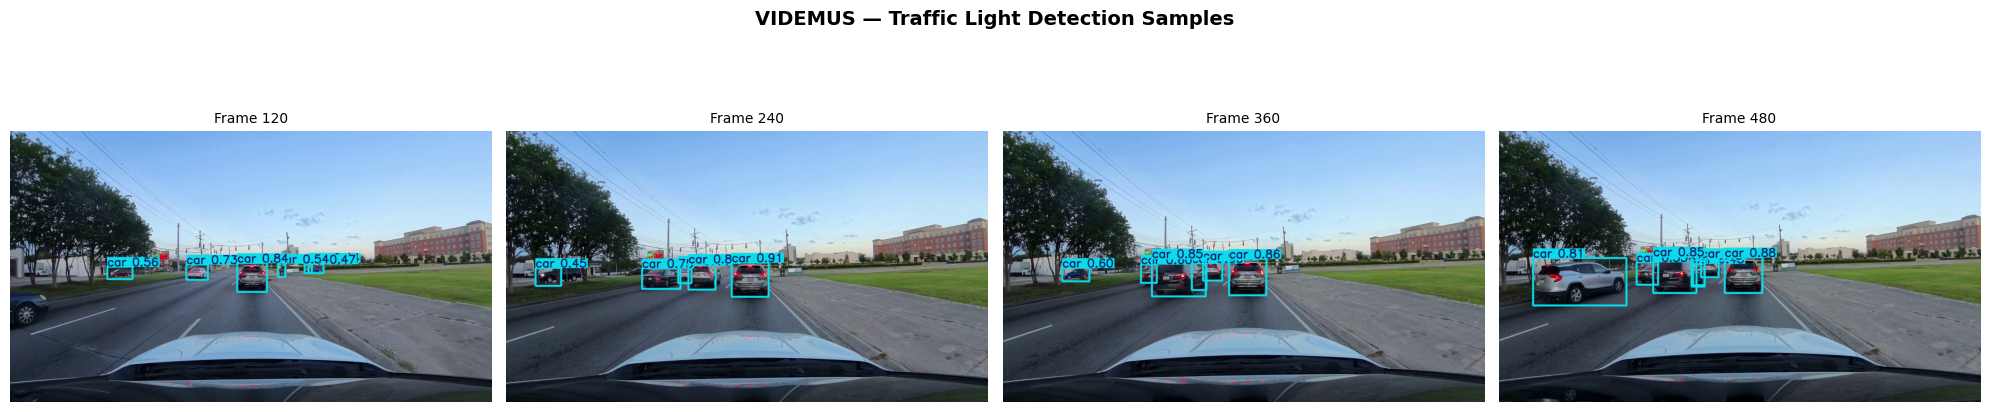

In [24]:
sample_indices = [int(total_frames * i / 5) for i in range(1, 5)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("VIDEMUS — Traffic Light Detection Samples", fontsize=14, fontweight='bold')

for idx, frame_num in enumerate(sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    if ret:
        result = model.predict(frame, conf=0.35, verbose=False)[0]
        annotated = result.plot()
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(annotated_rgb)
        axes[idx].set_title(f"Frame {frame_num}", fontsize=10)
    axes[idx].axis('off')

cap.release()
plt.tight_layout()
plt.show()

# Download the output video and model

In [25]:
from google.colab import files

# Download annotated video

In [26]:
if output_files:
    print("Downloading annotated video...")
    files.download(output_video)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Download trained model weights for future use

In [27]:
print("\nDownloading trained model weights...")
files.download(best_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
print("\nDone! You now have:")
print("  1. An annotated video showing detections")
print("  2. The best.pt model weights for deployment")


Done! You now have:
  1. An annotated video showing detections
  2. The best.pt model weights for deployment
